<a href="https://colab.research.google.com/github/dibadabir/Signal-Analysis/blob/main/Code%20Files/%20Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
!pip install openneuro-py
from pathlib import Path
import openneuro as on

In [31]:
# Dataset configuration
DATASET_ID = "ds003490"
BASE_DATA_DIR = Path("/content/data")
DATASET_DIR = BASE_DATA_DIR / DATASET_ID


In [32]:
# Create data directory if it does not exist
DATASET_DIR.parent.mkdir(parents=True, exist_ok=True)

print(f"Data will be downloaded to: {DATASET_DIR.resolve()}")


Data will be downloaded to: /content/data/ds003490


In [33]:
# Download dataset from OpenNeuro
on.download(
    dataset=DATASET_ID,
    target_dir=str(DATASET_DIR)
)

print("Download complete.")



👋 Hello! This is openneuro-py 2026.1.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds003490 …


📁 Traversing directories for ds003490 : 0 entities [00:00, ? entities/s]

📥 Retrieving up to 629 files (5 concurrent downloads). 
✅ Finished downloading ds003490.
 
🧠 Please enjoy your brains.
 
Download complete.


In [34]:
# Ensure the dataset directory exists; if not, re-attempt download with corrected target_dir
if not DATASET_DIR.exists():
    print(f"Dataset directory '{DATASET_DIR}' not found. Re-attempting download...")
    # The `target_dir` for openneuro.download should be the parent directory
    # where the dataset ID folder (ds003490) will be created.
    on.download(
        dataset=DATASET_ID,
        target_dir=str(BASE_DATA_DIR) # Corrected to BASE_DATA_DIR
    )
    # Re-check if directory exists after re-download attempt
    if not DATASET_DIR.exists():
        print(f"Error: Dataset directory '{DATASET_DIR}' still not found after re-download. Please check OpenNeuro dataset ID or permissions.")
    else:
        print(f"Re-download successful. Now inspecting files in '{DATASET_DIR}'.")

# Proceed to inspect files only if the directory now exists
if DATASET_DIR.exists():
    for path in list(DATASET_DIR.iterdir())[:10]:
        print(path)
else:
    print(f"Cannot inspect files as '{DATASET_DIR}' does not exist.")

/content/data/ds003490/sub-019
/content/data/ds003490/sub-001
/content/data/ds003490/sub-017
/content/data/ds003490/sub-009
/content/data/ds003490/sub-011
/content/data/ds003490/sub-003
/content/data/ds003490/participants.json
/content/data/ds003490/sub-028
/content/data/ds003490/sub-042
/content/data/ds003490/sub-050


In [35]:
!pip install mne mne-bids
import os
from pathlib import Path
import mne
from mne_bids import BIDSPath, read_raw_bids, get_entity_vals


In [36]:
BIDS_ROOT = Path("/content/data/ds003490")

print("BIDS root exists:", BIDS_ROOT.exists())
print("Subjects:", get_entity_vals(BIDS_ROOT, "subject")[:10])
print("Tasks:", get_entity_vals(BIDS_ROOT, "task")[:1])
print("Sessions:", get_entity_vals(BIDS_ROOT, "session")[:2])


BIDS root exists: True
Subjects: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010']
Tasks: ['Rest']
Sessions: ['01', '02']


In [37]:
subjects = get_entity_vals(BIDS_ROOT, "subject")
tasks = get_entity_vals(BIDS_ROOT, "task")
sessions = get_entity_vals(BIDS_ROOT, "session")  # may be empty depending on dataset

subject = subjects[0]
task = tasks[0] if tasks else None
session = sessions[0] if sessions else None

bids_path = BIDSPath(
    root=BIDS_ROOT,
    subject=subject,
    session=session,
    task=task,
    datatype="eeg"
)

raw = read_raw_bids(bids_path=bids_path, verbose=False)
raw.load_data()

print(raw)
print("Sampling rate:", raw.info["sfreq"])
print("Channels:", len(raw.ch_names))


Reading 0 ... 294099  =      0.000 ...   588.198 secs...


/tmp/ipython-input-2211731561.py:17: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = read_raw_bids(bids_path=bids_path, verbose=False)
/tmp/ipython-input-2211731561.py:17: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "Fp1" will be set to "misc".
  raw = read_raw_bids(bids_path=bids_path, verbose=False)
/tmp/ipython-input-2211731561.py:17: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "Fz" will be set to "misc".
  raw = read_raw_bids(bids_path=bids_path, verbose=False)
/tmp/ipython-input-2211731561.py:17: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "F3" will be set to "misc".
  raw = read_raw_bids(bids_path=bids_path, verbose=False)
/tmp/ipython-input-2211731561.py:17: RuntimeWarning: No BIDS -> MNE mapping found for channel type "n/a". Type of channel "F7" will be 

<RawEEGLAB | sub-001_ses-01_task-Rest_eeg.fdt, 67 x 294100 (588.2 s), ~150.4 MiB, data loaded>
Sampling rate: 500.0
Channels: 67


In [38]:
import numpy as np

# Check which channels have 3D positions after applying the montage
channels_with_loc = [ch_name for ch_name, ch_info in zip(raw.ch_names, raw.info['chs']) if np.any(ch_info['loc'][:3])]
channels_without_loc = [ch_name for ch_name, ch_info in zip(raw.ch_names, raw.info['chs']) if not np.any(ch_info['loc'][:3])]

print(f"Channels in raw data: {len(raw.ch_names)}")
print(f"Channels with 3D positions after montage: {len(channels_with_loc)}")
print(channels_with_loc)
print(f"\nChannels without 3D positions after montage: {len(channels_without_loc)}")
print(channels_without_loc)

# Print channels from the montage itself for comparison
print(f"\nChannels in the standard_1020 montage: {len(montage.ch_names)}")
print(montage.ch_names)

Channels in raw data: 67
Channels with 3D positions after montage: 67
['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'FCz', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'F2', 'AF4', 'AF8', 'VEOG', 'X', 'Y', 'Z']

Channels without 3D positions after montage: 0
[]

Channels in the standard_1020 montage: 94
['Fp1', 'Fpz', 'Fp2', 'AF9', 'AF7', 'AF5', 'AF3', 'AF1', 'AFz', 'AF2', 'AF4', 'AF6', 'AF8', 'AF10', 'F9', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'F10', 'FT9', 'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'FT10', 'T9', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8', 'T10', 'TP9', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'TP10', 'P9', 'P7

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edg

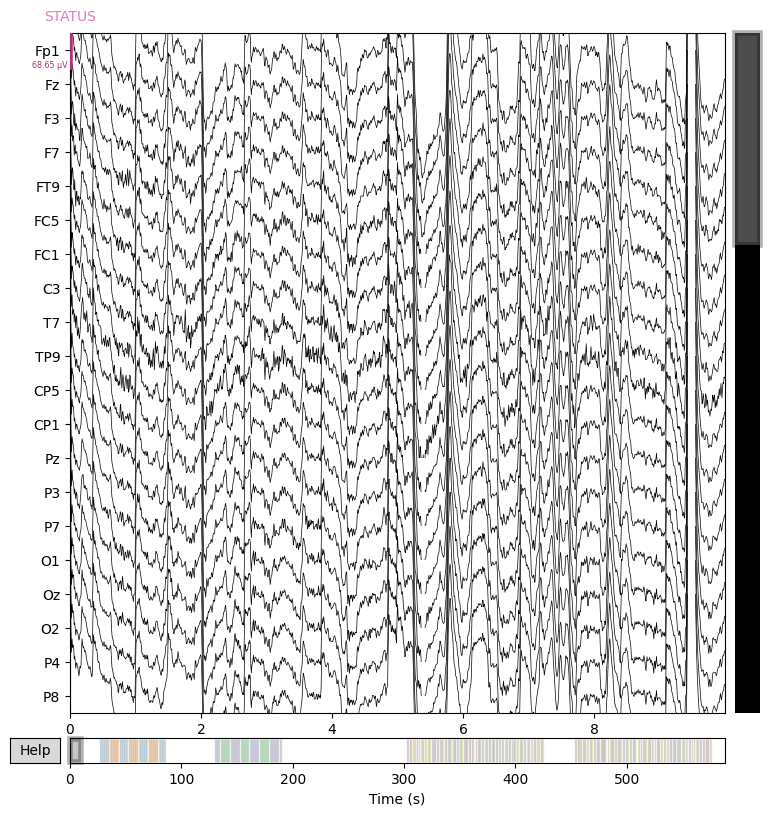

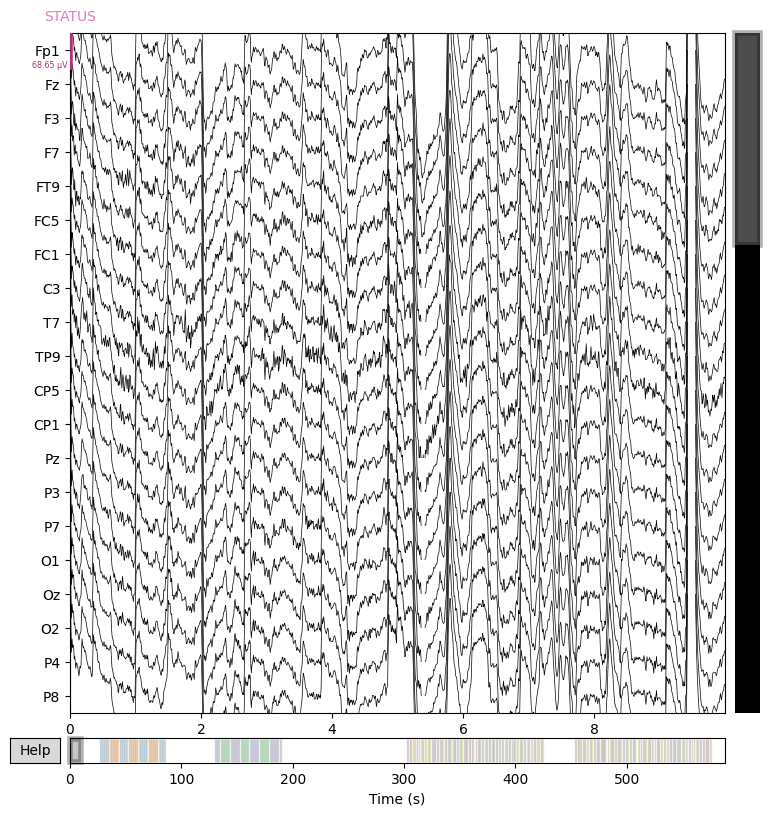

In [42]:
raw_clean = raw.copy()

# Ensure raw_clean has proper EEG channel types and montage for processing
# Re-apply channel type setting, assuming 'montage' is defined from previous steps
if 'montage' in locals():
    eeg_channels = [ch for ch in raw_clean.ch_names if ch not in ['X', 'Y', 'Z']]
    raw_clean.set_channel_types({ch: 'eeg' for ch in eeg_channels}, on_unit_change='ignore')
    raw_clean.set_montage(montage, on_missing="ignore")
else:
    print("Warning: 'montage' not defined. Cannot apply montage to raw_clean. Filtering might still fail if channel types are not implicitly correct.")
    # As a fallback, try to set 'eeg' channel types if montage is not available
    eeg_channels = [ch for ch in raw_clean.ch_names if ch not in ['X', 'Y', 'Z']]
    raw_clean.set_channel_types({ch: 'eeg' for ch in eeg_channels}, on_unit_change='ignore')

# Common steps for quick inspection (not your final pipeline)
raw_clean.filter(l_freq=1.0, h_freq=40.0, picks='eeg')
raw_clean.notch_filter(freqs=[50], picks='eeg')  # UK mains; add 60 if needed elsewhere
raw_clean.set_eeg_reference("average", projection=False)

raw_clean.plot(duration=10, n_channels=20, scalings="auto", picks='eeg')

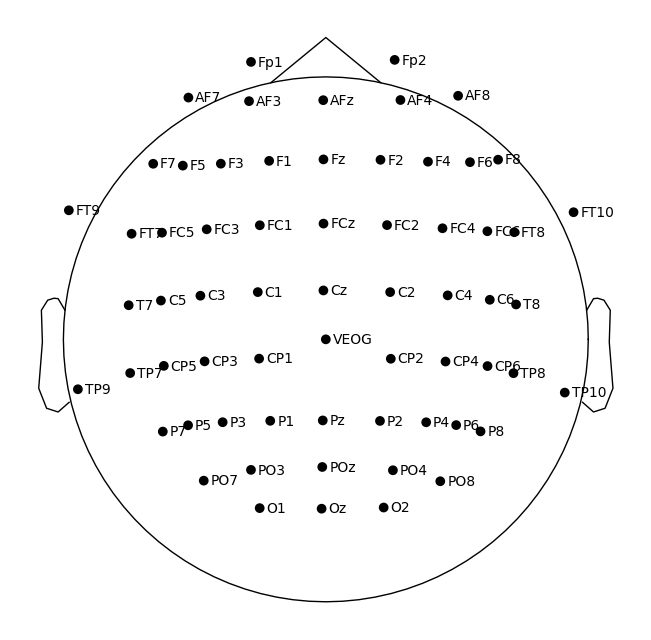

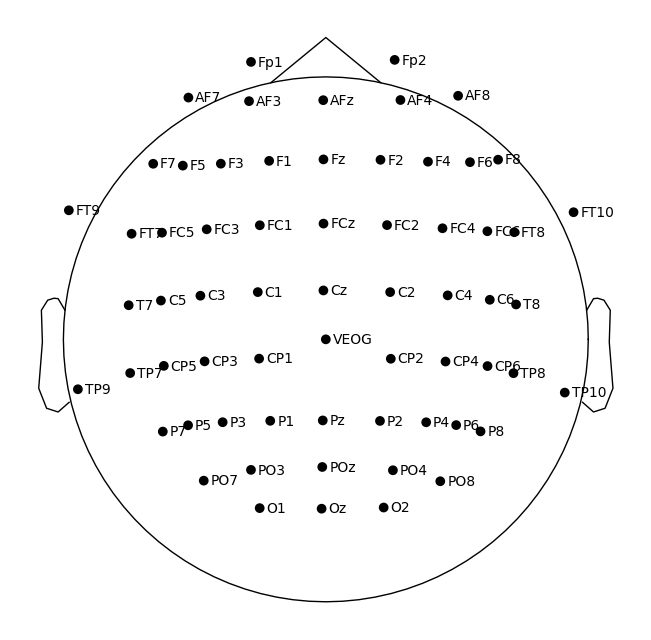

In [47]:
montage = mne.channels.make_standard_montage("standard_1020")

# Set channel types to 'eeg' for all channels except 'X', 'Y', 'Z'
eeg_channels = [ch for ch in raw.ch_names if ch not in ['X', 'Y', 'Z']]
raw.set_channel_types({ch: 'eeg' for ch in eeg_channels}, on_unit_change='ignore')

raw.set_montage(montage, on_missing="ignore")
raw.plot_sensors(show_names=True)